# 10. Implement K-Means with Python

First import the algorithm:

In [68]:
from sklearn.cluster import KMeans

Create a simple dataset:

In [69]:
import numpy as np

X = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [8, 8],
    [9, 8],
    [8, 9],
    [20, 2],
    [21, 3],
    [20, 4]
])

We can see that the points roughly from three groups.

# 11. Create the K-Means Model

In [70]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters = 3,
    random_state = 42
)

### Here:

n_clusters=3

### means:

We want three clusters.

### And:

random_state=42

makes the result reproducible.

# 12. Train the Model

In [71]:
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


Because K-Means is unsupervised, we only provide:

X

There is no:

y

because there are no predefined target labels.

# 13. Get Cluster Labels

In [72]:
labels = kmeans.labels_

For example, the output might look like:

[1, 1, 1, 0, 0, 0, 2, 2, 2]

The numbers are cluster IDs.

Important:

Cluster 0 is not inherently better than Cluster 1 or Cluster 2.

They are simply identifiers.

# 14. Get the Centroids

In [73]:
centers = kmeans.cluster_centers_

This returns the coordinates of the learned cluster centers.

For example:


[[ 8.33,  8.33],

 [ 1.33,  2.33],
 
 [20.33,  3.00]]

The exact order can vary.

# 15. Complete Basic Implementation

In [74]:
from sklearn.cluster import KMeans
import numpy as np

X = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [8, 8],
    [9, 8],
    [8, 9],
    [20, 2],
    [21, 3],
    [20, 4]
])

kmeans = KMeans(
    n_clusters = 3,
    random_state = 42
)

kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_


print("Labels:")
print(labels)

print("\nCentroids:")
print(centers)

print("\nInertia:")
print(kmeans.inertia_)

Labels:
[2 2 2 0 0 0 1 1 1]

Centroids:
[[ 8.33333333  8.33333333]
 [20.33333333  3.        ]
 [ 1.33333333  2.33333333]]

Inertia:
5.333333333333334


# 16. Visualize the Clusters

Visualization is extremely useful for understanding clustering.

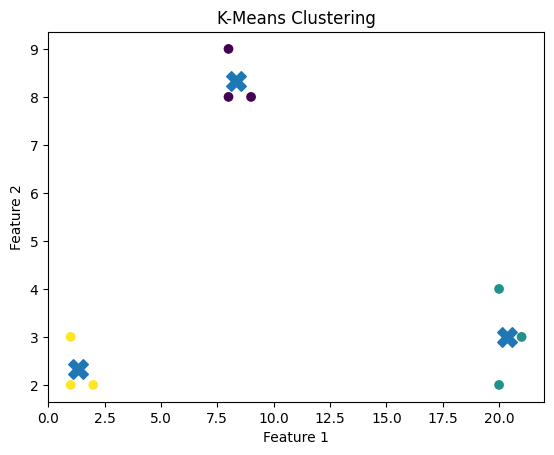

In [76]:
import matplotlib.pyplot as plt

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.show()

#### The X markers represent the centroids

# 17. fit() vs predict()

This distinction is important.

### fit()

Learns the clusters from the training data.

kmeans.fit(X)
### predict()

Assigns new data points to the nearest learned cluster.

In [80]:
new_points = np.array([
    [2, 3],
    [10, 9],
    [22, 3]
])

predictions = kmeans.predict(new_points)

print(predictions)

[2 0 1]


### So:

### fit()

↓

Learn centroids

### predict()

↓

Assign new points to clusters

# 18. fit_predict()

## You can also do both in one operation:

In [88]:
labels = kmeans.fit_predict(X)

## This is equivalent to:

In [85]:
kmeans.fit(X)
labels = kmeans.predict(X)

#### For learning purposes, understand both approaches.

# 19. Important Limitation: Feature Scaling

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters = 3,
    random_state = 42
)

labels = kmeans.fit_predict(X_scaled)

#### Remember:

### K-Means + distance → always think about feature scaling.